<a href="https://colab.research.google.com/github/LinaGitCoder/Survival-Analysis-Customer-Retention/blob/main/Survival_Analysis_Customer_Retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJET : DATA SCIENCE**
**TP ANALYSE DE SURVIE 2026**

---


**Amrani Lina**

# **Contexte et Objectifs**

Dans le cadre de ce TP, nous allons mener une étude approfondie sur des données cliniques de survie. L'analyse de survie est une branche des statistiques qui s'intéresse au temps écoulé avant qu'un événement d'intérêt (ici, le décès) ne se produise.

Notre démarche se structurera en cinq étapes clés :

**1.  Préparation de l'environnement :**
Importation des librairies spécialisées (lifelines, plotly).

**2.  Exploration des données (EDA) :** Compréhension de la distribution des variables et gestion des données censurées.

**3.  Approche non-paramétrique (Kaplan-Meier) :** Estimation des courbes de survie et comparaison entre groupes (ex: Hommes vs Femmes) avec tests statistiques (Log-Rank).

**4.  Analyse du risque (Nelson-Aalen) :** Étude de la dynamique du risque cumulé au cours du temps.

**5.  Modélisation multivariée (Régression de Cox) :** Identification et quantification des facteurs de risque (tabac, traitement, activité physique) influençant la survie.


# **1. Installation et Importations**




In [ ]:
# Installation des librairies nécessaires
!pip install lifelines plotly pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go # Pour les graphes interactifs
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter

# Modules spécifiques à l'analyse de survie
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Configuration du style graphique
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import plotly.graph_objects as go #POUR LE GRAPHIQUE INTERACTIF


# **2. Chargement des données**

Nous commençons par charger le jeu de données **survival_data_1000.csv**. Cette étape inclut une vérification de l'intégrité des données (types de variables, valeurs manquantes) pour s'assurer de la qualité de l'analyse. Nous vérifions notamment la présence des deux colonnes critiques pour l'analyse de survie :

*   **Time_to_Event** : La durée de suivi
(en mois).

*   **Event_Observed** : L'indicateur de l'événement (1 = Décès observé, 0 = Censure/Perdu de vue).

In [ ]:
# Lecture du fichier de données
# On vérifie que le fichier est là. S'il n'est pas là, on ouvre une boîte de dialogue pour l'uploader.

fichier_csv = "survival_data_1000.csv"

if not os.path.exists(fichier_csv):
    print(f"Le fichier '{fichier_csv}' est introuvable !")
    print("Veuillez le sélectionner dans la fenêtre qui va s'ouvrir ci-dessous :")

    try:
        from google.colab import files
        uploaded = files.upload()
        # On prend le premier fichier uploadé si le nom diffère
        if fichier_csv not in uploaded.keys():
            fichier_csv = list(uploaded.keys())[0]
        print(f" Fichier '{fichier_csv}' chargé avec succès !")
    except ImportError:
        print(" Erreur : Impossible d'utiliser l'upload Google Colab en local.")
        sys.exit("Arrêt du script : Veuillez mettre le fichier CSV dans le dossier.")

# Chargement du dataframe
df = pd.read_csv(fichier_csv)

# Vérification du contenu
print(df.shape)
print(df.head())
print(df.info())

(1000, 9)
   Age     Sex  Smoker  Comorbidities Treatment  BMI Physical_Activity  \
0   73  Female       0              0  Standard   23          Moderate   
1   55    Male       1              1  Standard   20          Moderate   
2   60  Female       0              1  Standard   30          Moderate   
3   56    Male       0              1  Standard   28               Low   
4   72  Female       0              1  Standard   37              High   

   Time_to_Event  Event_Observed  
0      63.839174               0  
1      67.477398               1  
2      79.181521               1  
3      14.761940               1  
4      17.227929               1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Sex                1000 non-null   object 
 2   Smoker             1000 non-null 

# **3. Pré-traitement et transformations des variables**

Pour faciliter l'interprétation clinique, certaines variables continues gagnent à être transformées en catégories (bins). Nous allons ici :

*   Créer des tranches d'âge (<50, 50-60, >60) pour identifier des effets de seuil.

*   Catégoriser l'IMC (BMI) pour isoler les profils à risque (maigreur, poids normal, surpoids/obésité).

## Création des tranches d'âge

In [ ]:
# Création de la variable Tranche_Age (<50, 50-60, >60)
df["Tranche_Age"] = pd.cut(df["Age"],
                           bins=[0, 50, 60, 120], # 120 est une borne sup arbitraire pour inclure tous les >60
                           labels=["<50", "50-60", ">60"])

## Création des tranches de BMI  (Body Mass Index)

In [ ]:
# Création de la variable Tranche_BMI (<18, 18-26, >26)
df["Tranche_BMI"] = pd.cut(
    df["BMI"],
    bins=[0, 18, 26, 100],
    labels=["<18", "18-26", ">26"])

## Aperçu des transformations

In [ ]:
print(f"Données chargées : {df.shape[0]} patients, {df.shape[1]} variables.")
display(df.head())

Données chargées : 1000 patients, 11 variables.


,Age,Sex,Smoker,Comorbidities,Treatment,BMI,Physical_Activity,Time_to_Event,Event_Observed,Tranche_Age,Tranche_BMI
0,73,Female,0,0,Standard,23,Moderate,63.839174,0,>60,18-26
1,55,Male,1,1,Standard,20,Moderate,67.477398,1,50-60,18-26
2,60,Female,0,1,Standard,30,Moderate,79.181521,1,50-60,>26
3,56,Male,0,1,Standard,28,Low,14.761940,1,50-60,>26
4,72,Female,0,1,Standard,37,High,17.227929,1,>60,>26


# Analyse exploratoire des données
Pour explorer les données de façon interactive, nous utilisons Plotly.

In [ ]:
# 1. Statistiques descriptives pour toutes les variables numériques
# (Age, BMI, Time_to_Event, etc.)
print("--- Statistiques des variables numériques ---")
display(df.describe())

# 2. Exploration automatique de toutes les variables catégorielles ou binaires
# (Sex, Smoker, Comorbidities, Treatment, Physical_Activity, Event_Observed)
print("\n--- Fréquences des variables catégorielles ---")

# On liste les colonnes qualitatives ou binaires
cols_cat = ['Smoker', 'Comorbidities', 'Treatment', 'Physical_Activity', 'Event_Observed']

for col in cols_cat:
    print(f"\nRépartition pour : {col}")
    # normalize=True donne le pourcentage, count() donne l'effectif
    stats = pd.DataFrame({
        'Effectif': df[col].value_counts(),
        'Pourcentage (%)': df[col].value_counts(normalize=True) * 100
    })
    display(stats)

--- Statistiques des variables numériques ---


,Age,Smoker,Comorbidities,BMI,Time_to_Event,Event_Observed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,59.603000,0.388000,0.966000,24.534000,42.420523,0.711000
std,9.871009,0.487538,0.916343,5.189391,53.967320,0.453525
min,31.000000,0.000000,0.000000,9.000000,0.051313,0.000000
25%,53.000000,0.000000,0.000000,21.000000,9.722772,0.000000
50%,59.000000,0.000000,1.000000,25.000000,23.819866,1.000000
75%,67.000000,1.000000,1.000000,28.000000,52.941360,1.000000
max,87.000000,1.000000,5.000000,41.000000,457.199295,1.000000



--- Fréquences des variables catégorielles ---

Répartition pour : Smoker


,Effectif,Pourcentage (%)
Smoker,,
0,612,61.2
1,388,38.8



Répartition pour : Comorbidities


...

,Effectif,Pourcentage (%)
Treatment,,
Standard,726,72.6
Experimental,274,27.4



Répartition pour : Physical_Activity


,Effectif,Pourcentage (%)
Physical_Activity,,
Moderate,490,49.0
Low,293,29.3
High,217,21.7



Répartition pour : Event_Observed


,Effectif,Pourcentage (%)
Event_Observed,,
1,711,71.1
0,289,28.9


In [ ]:
# ==========================================================
# 1. ANALYSE DES VARIABLES NUMÉRIQUES (Tableau + Graphiques)
# ==========================================================
print("--- 📊 Statistiques des variables numériques ---")
display(df[['Age', 'BMI', 'Time_to_Event']].describe())

# --- Distribution de l'Âge ---
mean_age = df['Age'].mean()
fig_age = px.histogram(df, x="Age", nbins=30, marginal="violin",
                       title=f"Distribution de l'Âge (Moyenne : {mean_age:.1f} ans)",
                       color_discrete_sequence=['#3498db'], template="plotly_white")
fig_age.add_vline(x=mean_age, line_dash="dash", line_color="red",
                  annotation_text=f"Moyenne: {mean_age:.1f}")
fig_age.show()

# --- Distribution du BMI ---
fig_bmi = px.histogram(df, x="BMI", nbins=30, marginal="box",
                       title="Distribution du BMI (Seuil Obésité : 30)",
                       color_discrete_sequence=['#e67e22'], template="plotly_white")
fig_bmi.add_vline(x=30, line_dash="solid", line_color="red", line_width=2)
fig_bmi.show()

# --- Distribution du Temps de Suivi ---
fig_time = px.histogram(df, x="Time_to_Event", nbins=50,
                        title="Distribution du Temps jusqu'à l'événement (Suivi)",
                        color_discrete_sequence=['#2ecc71'], template="plotly_white")
fig_time.show()


# ==========================================================
# 2. ANALYSE DES VARIABLES CATÉGORIELLES (Tableau + Visuel Corrigé)
# ==========================================================
print("\n--- 📋 Fréquences et Visuels des variables catégorielles ---")

cols_cat = ['Sex', 'Smoker', 'Comorbidities', 'Treatment', 'Physical_Activity', 'Event_Observed']
colors = ['#1abc9c', '#9b59b6', '#34495e', '#f1c40f', '#e74c3c', '#27ae60']

for i, col in enumerate(cols_cat):
    # 1. Création du tableau de statistiques
    print(f"\n▶ Répartition pour la variable : {col}")
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100

    stats = pd.DataFrame({
        'Effectif': counts,
        'Pourcentage (%)': percents
    })
    display(stats)

    # Préparation des données pour Plotly (on nomme explicitement l'index)
    plot_df = stats.reset_index()
    plot_df.columns = [col, 'Effectif', 'Pourcentage (%)']

    # 2. Création du visuel dynamique
    if col in ['Sex', 'Event_Observed']:
        # Utilisation de names=col pour éviter l'erreur sur 'index'
        fig = px.pie(plot_df, names=col, values='Effectif',
                     title=f"Répartition : {col}",
                     hole=0.5,
                     color_discrete_sequence=[colors[i], '#bdc3c7'])
        fig.update_traces(textinfo='percent+label')
    else:
        fig = px.bar(plot_df, x=col, y='Effectif',
                     title=f"Distribution : {col}",
                     text=plot_df['Pourcentage (%)'].apply(lambda x: f"{x:.1f}%"),
                     color=col,
                     color_discrete_sequence=[colors[i], colors[(i+1)%len(colors)]],
                     template="plotly_white")
        fig.update_layout(showlegend=False)

    fig.show()

--- 📊 Statistiques des variables numériques ---


,Age,BMI,Time_to_Event
count,1000.000000,1000.000000,1000.000000
mean,59.603000,24.534000,42.420523
std,9.871009,5.189391,53.967320
min,31.000000,9.000000,0.051313
25%,53.000000,21.000000,9.722772
50%,59.000000,25.000000,23.819866
75%,67.000000,28.000000,52.941360
max,87.000000,41.000000,457.199295



--- 📋 Fréquences et Visuels des variables catégorielles ---

▶ Répartition pour la variable : Sex


,Effectif,Pourcentage (%)
Sex,,
Male,506,50.6
Female,494,49.4



▶ Répartition pour la variable : Smoker


...

,Effectif,Pourcentage (%)
Treatment,,
Standard,726,72.6
Experimental,274,27.4



▶ Répartition pour la variable : Physical_Activity


,Effectif,Pourcentage (%)
Physical_Activity,,
Moderate,490,49.0
Low,293,29.3
High,217,21.7



▶ Répartition pour la variable : Event_Observed


,Effectif,Pourcentage (%)
Event_Observed,,
1,711,71.1
0,289,28.9


In [ ]:
# Distribution du Temps de Suivi
fig = px.histogram(df, x="Time_to_Event", nbins=50,
                   title="Distribution du Temps jusqu'à l'événement",
                   color_discrete_sequence=['#2ecc71'])
fig.update_layout(bargap=0.1)
fig.show()

**Analyse de la Figure "Distribution du Temps" :**

Le graphique ci-dessus montre que la distribution des temps de suivi n'est pas gaussienne (normale) mais asymétrique à droite (ressemblant à une loi exponentielle ou de Weibull).
*   Une grande partie des événements ou censures surviennent tôt dans l'étude (entre 0 et 50 mois).

*   Cette distribution justifie l'utilisation de méthodes spécifiques à l'analyse de survie (Kaplan-Meier, Cox) plutôt que des régressions linéaires classiques qui supposent une normalité des résidus.

In [ ]:
#Comparaison Décès vs Censure
fig = px.histogram(df, x="Event_Observed", color="Event_Observed",
                   title="Répartition des évenements : Nombre de patients Censurés (0) vs Décédés (1)",
                   labels={"Event_Observed": "Statut (0=Censuré, 1=Décès)"})
fig.show()

**Analyse de la Figure "Ratio Censure / Décès" :**

 Ce graphique met en évidence l'équilibre des classes. Nous observons une proportion importante de patients décédés (1) par rapport aux patients censurés (0). Bien que le taux d'événements soit élevé, la présence de données censurées (patients n'ayant pas subi l'événement à la fin de l'étude) rend indispensable l'utilisation de l'estimateur de Kaplan-Meier pour ne pas biaiser les estimations de survie à la baisse.

# **4. Analyse de Survie avec la méthode de KAPLAN-MEIER**

L'estimateur de **Kaplan-Meier** nous permet de calculer la probabilité de survie $S(t)$ à chaque instant $t$. Contrairement à une simple moyenne, il gère correctement les données censurées en ajustant la population à risque à chaque pas de temps.

In [ ]:
kmf = KaplanMeierFitter()
kmf.fit(df["Time_to_Event"], event_observed=df["Event_Observed"], label="Survie globale")

sf = kmf.survival_function_.reset_index()
ci = kmf.confidence_interval_.reset_index()
ci = ci.rename(columns={'index': 'timeline'})

t_col = sf.columns[0]
s_col = sf.columns[1]
lower_col = ci.columns[1]
upper_col = ci.columns[2]

fig = go.Figure()

# courbe de survie
fig.add_trace(go.Scatter(
    x=sf[t_col], y=sf[s_col],
    mode="lines",
    name="Survie (KM)"
))

# bande IC 95%
fig.add_trace(go.Scatter(
    x=ci[t_col], y=ci[upper_col],
    mode="lines",
    line=dict(width=0),
    showlegend=False
))
fig.add_trace(go.Scatter(
    x=ci[t_col], y=ci[lower_col],
    mode="lines",
    fill="tonexty",
    line=dict(width=0),
    name="IC 95%"
))

fig.update_layout(
    title="Kaplan–Meier (global)",
    xaxis_title="Temps (mois)",
    yaxis_title="Probabilité de survie",
    hovermode="x unified"
)

fig.show()

**Analyse de la Courbe de Survie Globale :**

*   Tendance : La probabilité de survie chute rapidement durant les 50 premiers mois, passant de 100% à environ 40%, avant de se stabiliser et de décroître plus lentement.

*   Incertitude : La zone ombrée représente l'intervalle de confiance à 95%. On remarque que cet intervalle s'élargit vers la fin de la période (après 200 mois), car le nombre de patients encore "à risque" diminue, rendant l'estimation moins précise.

**COMPARAISON HOMME / FEMME :**

In [ ]:
# KAPLAN-MEIER selon le sexe : COMPARAISON HOMME vs FEMME
fig = go.Figure()

for sex in df["Sex"].unique():
    mask = df["Sex"] == sex
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "Time_to_Event"], df.loc[mask, "Event_Observed"], label=str(sex))
    sf = kmf.survival_function_.reset_index()

    t_col = sf.columns[0]
    s_col = sf.columns[1]

    fig.add_trace(go.Scatter(
        x=sf[t_col], y=sf[s_col],
        mode="lines",
        name=f"{sex}"
    ))

fig.update_layout(
    title="Dynamique de survie selon le sexe",
    xaxis_title="Temps (mois)",
    yaxis_title="Probabilité de survie",
    hovermode="x unified"
)
fig.show()

In [ ]:
# Test statistique (Log-Rank)
T_m, E_m = df[df['Sex']=='Male']['Time_to_Event'], df[df['Sex']=='Male']['Event_Observed']
T_f, E_f = df[df['Sex']=='Female']['Time_to_Event'], df[df['Sex']=='Female']['Event_Observed']
results = logrank_test(T_m, T_f, event_observed_A=E_m, event_observed_B=E_f)

print(f"\nRÉSULTAT DU TEST LOG-RANK :\n p-value = {results.p_value:.5f}")
if results.p_value < 0.05:
    print("Conclusion : Différence significative entre Hommes et Femmes.")
else:
    print("Conclusion : Pas de différence significative.")


RÉSULTAT DU TEST LOG-RANK :
 p-value = 0.82746
Conclusion : Pas de différence significative.


**Analyse Comparée (Hommes vs Femmes) :**


Le visuel montre deux courbes de survie (Rouge et Bleue) qui se chevauchent presque parfaitement tout au long de l'étude.

***Test du Log-Rank :***

Le test statistique confirme cette observation visuelle. Avec une p-value de 0.82 (supérieure au seuil standard de 0.05), nous ne pouvons pas rejeter l'hypothèse nulle.

***Conclusion :***

Il n'y a pas de différence significative de survie entre les hommes et les femmes dans cet échantillon. Le sexe ne semble pas être un facteur déterminant ici.

## **Autres comparaisons**

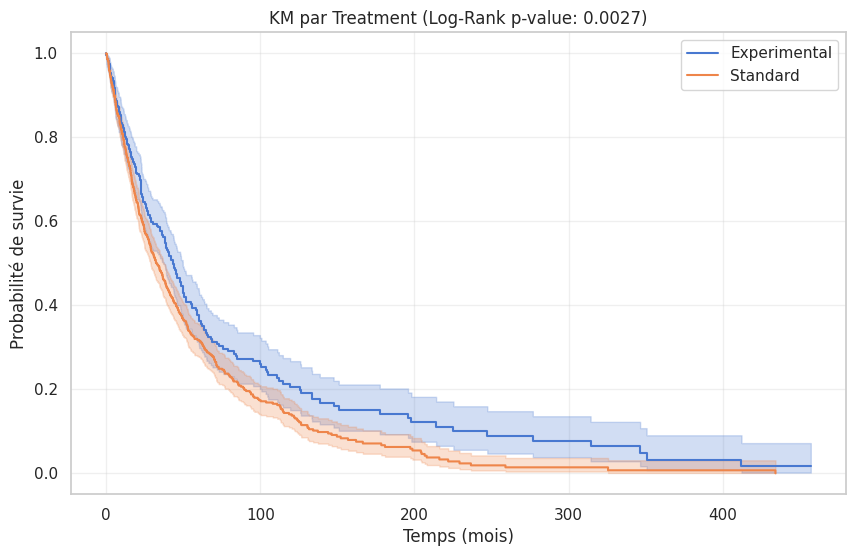

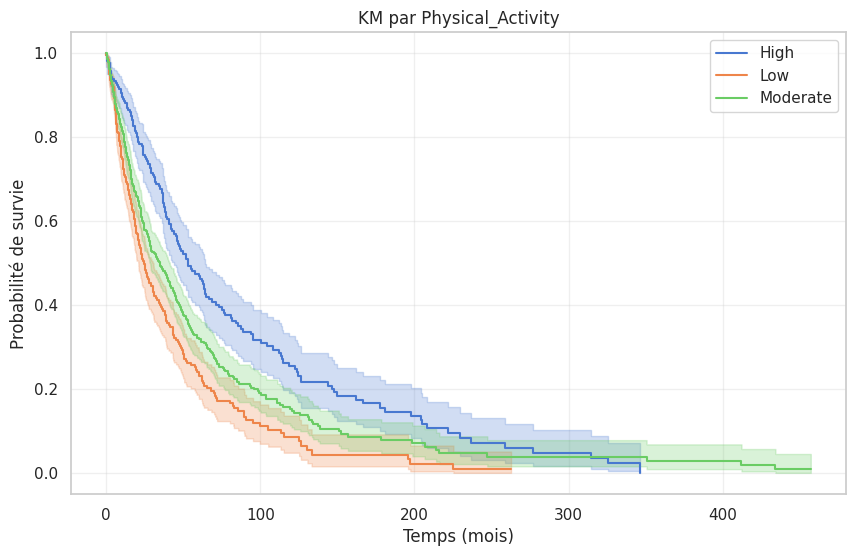

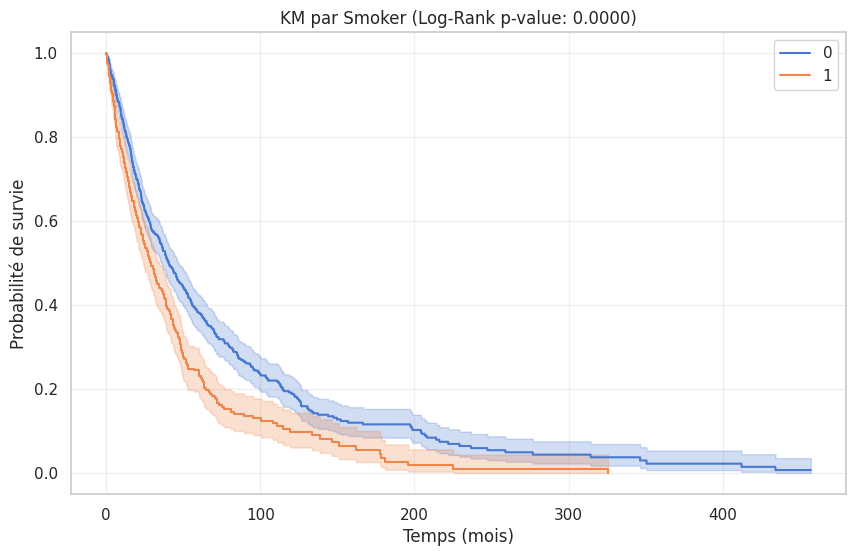

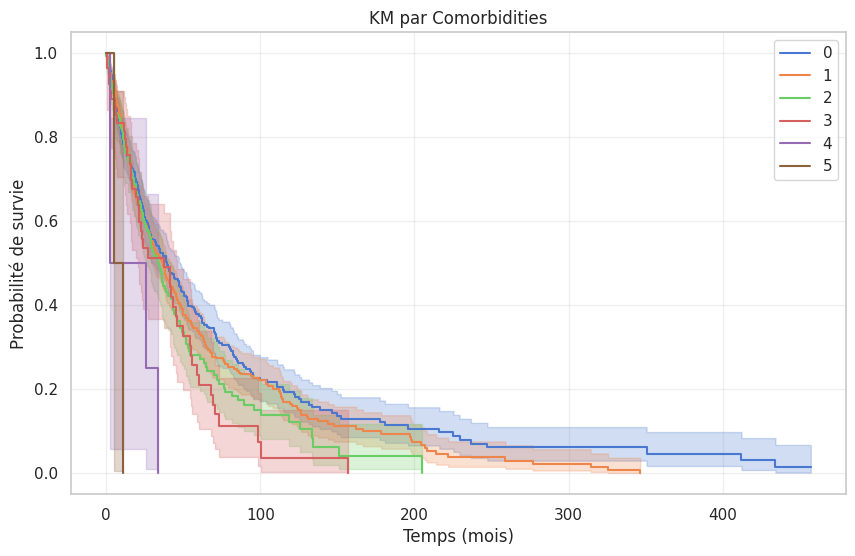

In [ ]:
# Liste des variables à tester
variables_a_tester = ['Treatment', 'Physical_Activity', 'Smoker', 'Comorbidities']

for var in variables_a_tester:
    plt.figure(figsize=(10, 6))
    kmf = KaplanMeierFitter()

    # Tracer une courbe pour chaque modalité de la variable
    for name, grouped_df in df.groupby(var):
        kmf.fit(grouped_df['Time_to_Event'], grouped_df['Event_Observed'], label=name)
        kmf.plot_survival_function()

    # Calcul du test Log-Rank entre les deux premiers groupes pour l'exemple
    categories = df[var].unique()
    if len(categories) == 2:
        results = logrank_test(
            df[df[var] == categories[0]]['Time_to_Event'],
            df[df[var] == categories[1]]['Time_to_Event'],
            event_observed_A=df[df[var] == categories[0]]['Event_Observed'],
            event_observed_B=df[df[var] == categories[1]]['Event_Observed']
        )
        plt.title(f"KM par {var} (Log-Rank p-value: {results.p_value:.4f})")
    else:
        plt.title(f"KM par {var}")

    plt.ylabel("Probabilité de survie")
    plt.xlabel("Temps (mois)")
    plt.grid(alpha=0.3)
    plt.show()

# **5. Fonction de Risque Cumulé (Nelson-Aalen)**

Alors que Kaplan-Meier se concentre sur la survie (la chance de ne pas mourir), l'estimateur de **Nelson-Aalen** estime le risque cumulé $H(t)$ (la somme des risques instantanés subis jusqu'au temps $t$). C'est un indicateur précieux pour comprendre comment le danger s'accumule au fil du temps.

In [ ]:
# FONCTION DE RISQUE CUMULÉ (NELSON-AALEN)
naf = NelsonAalenFitter()
naf.fit(
    df["Time_to_Event"],
    event_observed=df["Event_Observed"]
)

<lifelines.NelsonAalenFitter:"NA_estimate", fitted with 1000 total observations, 289 right-censored observations>

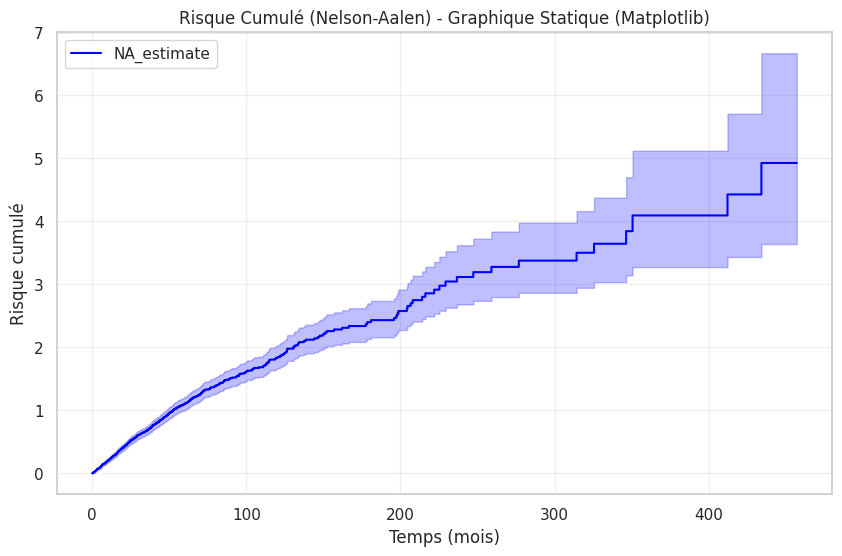

In [ ]:
# ÉTAPE PRÉALABLE : Calcul du modèle Nelson-Aalen
naf = NelsonAalenFitter()
naf.fit(df["Time_to_Event"], df["Event_Observed"])


# =========================================================
# FIGURE 1 : VERSION STATIQUE
# =========================================================
plt.figure(figsize=(10, 6))

# Cette fonction affiche automatiquement l'intervalle de confiance (les "bords" bleus)
naf.plot_cumulative_hazard(color="blue")

plt.title("Risque Cumulé (Nelson-Aalen) - Graphique Statique (Matplotlib)")
plt.xlabel("Temps (mois)")
plt.ylabel("Risque cumulé")
plt.grid(True, alpha=0.3)

plt.show()


# =========================================================
# FIGURE 2 : VERSION DYNAMIQUE (Interactive)
# =========================================================
# Récupération des données pour Plotly
df_na = naf.cumulative_hazard_.reset_index()
df_na.columns = ['Temps', 'Risque_Cumulé']

fig_na = go.Figure()

# Ajout de la courbe (Zone remplie comme sur votre image)
fig_na.add_trace(go.Scatter(
    x=df_na['Temps'],
    y=df_na['Risque_Cumulé'],
    fill='tozeroy',       # Remplit la zone sous la courbe
    mode='lines',
    line=dict(color='purple'),
    name="Risque Cumulé"
))

fig_na.update_layout(
    title="Évolution du Risque Cumulé (Interactive)",
    xaxis_title="Temps (mois)",
    yaxis_title="Risque Cumulé H(t)",
    template="plotly_white"
)

fig_na.show()

**Analyse de la Fonction de Risque :**

La courbe est croissante (le risque cumulé ne peut qu'augmenter).

***Forme :*** La pente est relativement forte au début, ce qui indique un taux de mortalité (hazard rate) élevé dans les premiers mois.

***Convexité :*** La courbe semble légèrement concave par endroits, suggérant que le taux de risque instantané pourrait diminuer ou se stabiliser pour les survivants à long terme.

In [ ]:
#Probabilité estimée qu’un patient survive au-delà de t mois.
t = 6  # exemple : 6 mois
kmf.predict(t)

np.float64(0.8799618312489415)

In [ ]:
t = 12  # exemple : 12 mois
kmf.predict(t)

np.float64(0.7929238342785462)

In [ ]:
t = 24  # exemple : 24 mois
kmf.predict(t)

np.float64(0.6106062524795269)

In [ ]:
t = 48  # exemple : 48 mois
kmf.predict(t)

np.float64(0.4078851910709779)

# **6. Analyse Multivariée : Modèle à Risques Proportionnels de Cox**

Jusqu'à présent, nous avons regardé les variables isolément. Le modèle de Cox permet d'évaluer l'impact simultané de plusieurs facteurs (Âge, Tabac, Traitement, Activité) sur le risque de décès.Le modèle estime des Hazard Ratios (HR) :

$HR > 1$ : Facteur aggravant (augmente le risque).

$HR < 1$ : Facteur protecteur (diminue le risque).

$HR = 1$ : Aucun effet.

In [ ]:
# Analyse Multivariée (Modèle de Cox)

# Encodage : Préparer les données (sélection des colonnes utiles)
cols_cox = ['Time_to_Event', 'Event_Observed', 'Age', 'Sex', 'Smoker', 'Treatment', 'Physical_Activity']
df_cox = pd.get_dummies(df[cols_cox], drop_first=True)

# Modèle
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Time_to_Event', event_col='Event_Observed')

# Affichage des Hazard Ratios
print("Impact des variables (Hazard Ratios) :")
cph.print_summary()

# Visualisation simplifiée des coefficients
summary_df = cph.summary.reset_index()
fig_cox = px.bar(summary_df, x="exp(coef)", y="covariate", orientation='h',
                 title="Impact sur le Risque de Décès (Hazard Ratio)",
                 labels={"exp(coef)": "Hazard Ratio ( >1 = Risque, <1 = Protection)", "covariate": "Variable"})
fig_cox.add_vline(x=1, line_dash="dash", line_color="red", annotation_text="Neutre")
fig_cox.show()

Impact des variables (Hazard Ratios) :


<lifelines.CoxPHFitter: fitted with 1000 total observations, 289 right-censored observations>
             duration col = 'Time_to_Event'
                event col = 'Event_Observed'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 711
   partial log-likelihood = -4126.67
         time fit was run = 2026-02-05 14:32:59 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
Age                         0.03      1.03      0.00            0.03            0.04                1.03                1.04
Smoker                      0.39      1.48      0.08            0.24            0.55                1.27                1.73
Sex_Male                   -0.03      0.97      0.08           -0.18            0.12                0.83                1.12
Treatment_Standard          0.34      1.41      0.09            0.17            0.51                1.19                1.67
Physical_Activity_Low       0.73      2.08      0.11            0.52            0.94                1.69                2.57
Physical_Activity_Moderate  0.38      1.46      0.10            0.19            0.57                1.21                1.77

                            cmp to     z      p  -log2(p)
covariate                                                
Age                           0.00  8.60 <0.005     56.83
Smoker                        0.00  4.96 <0.005     20.44
Sex_Male                      0.00 -0.44   0.66      0.60
Treatment_Standard            0.00  3.99 <0.005     13.90
Physical_Activity_Low         0.00  6.83 <0.005     36.77
Physical_Activity_Moderate    0.00  3.88 <0.005     13.23
---
Concordance = 0.64
Partial AIC = 8265.33
log-likelihood ratio test = 148.19 on 6 df
-log2(p) of ll-ratio test = 95.44


📊 --- 5. Analyse Multivariée (Modèle de Cox Avancé) ---

--- Résumé du Modèle ---


<lifelines.CoxPHFitter: fitted with 1000 total observations, 289 right-censored observations>
             duration col = 'Time_to_Event'
                event col = 'Event_Observed'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 711
   partial log-likelihood = -4126.67
         time fit was run = 2026-02-05 14:33:00 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
Age                         0.03      1.03      0.00            0.03            0.04                1.03                1.04
Smoker                      0.39      1.48      0.08            0.24            0.55                1.27                1.73
Sex_Male                   -0.03      0.97      0.08           -0.18            0.12                0.83                1.12
Treatment_Standard          0.34      1.41      0.09            0.17            0.51                1.19                1.67
Physical_Activity_Low       0.73      2.08      0.11            0.52            0.94                1.69                2.57
Physical_Activity_Moderate  0.38      1.46      0.10            0.19            0.57                1.21                1.77

                            cmp to     z      p  -log2(p)
covariate                                                
Age                           0.00  8.60 <0.005     56.83
Smoker                        0.00  4.96 <0.005     20.44
Sex_Male                      0.00 -0.44   0.66      0.60
Treatment_Standard            0.00  3.99 <0.005     13.90
Physical_Activity_Low         0.00  6.83 <0.005     36.77
Physical_Activity_Moderate    0.00  3.88 <0.005     13.23
---
Concordance = 0.64
Partial AIC = 8265.33
log-likelihood ratio test = 148.19 on 6 df
-log2(p) of ll-ratio test = 95.44


--- Classement des Facteurs de Risque (Hazard Ratios) ---
 covariate
Physical_Activity_Low         2.082242
Smoker                        1.479180
Physical_Activity_Moderate    1.463238
Treatment_Standard            1.407930
Age                           1.034204
Sex_Male                      0.967044
Name: coef, dtype: float64

--- Vérification des Hypothèses (Proportional Hazards) ---

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportion



1. Variable 'Physical_Activity_Moderate' failed the non-proportional test: p-value is 0.0313.

   Advice: with so few unique values (only 2), you can include
`strata=['Physical_Activity_Moderate', ...]` in the call in `.fit`. See documentation in link [E]
below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



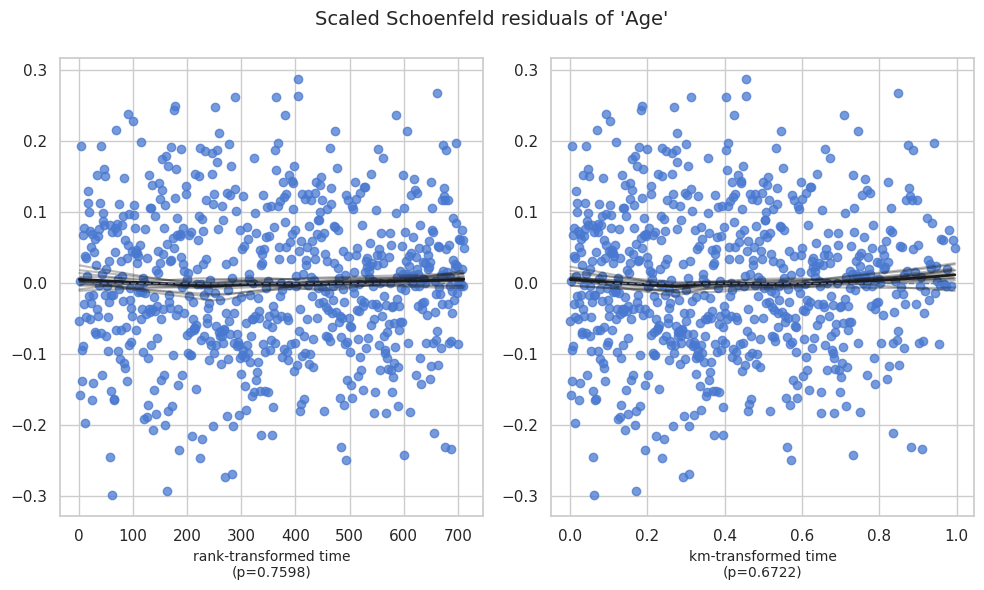

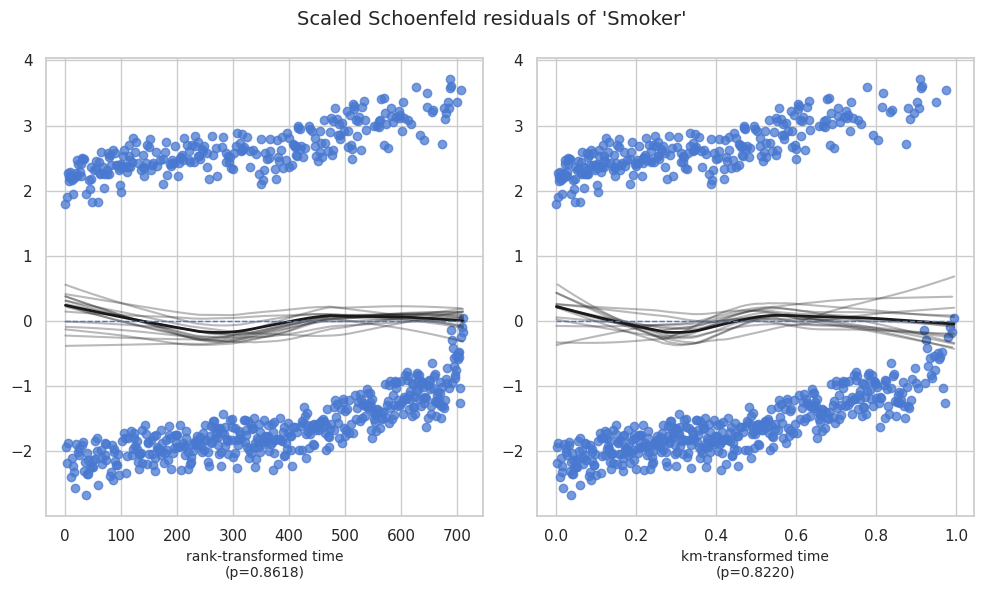

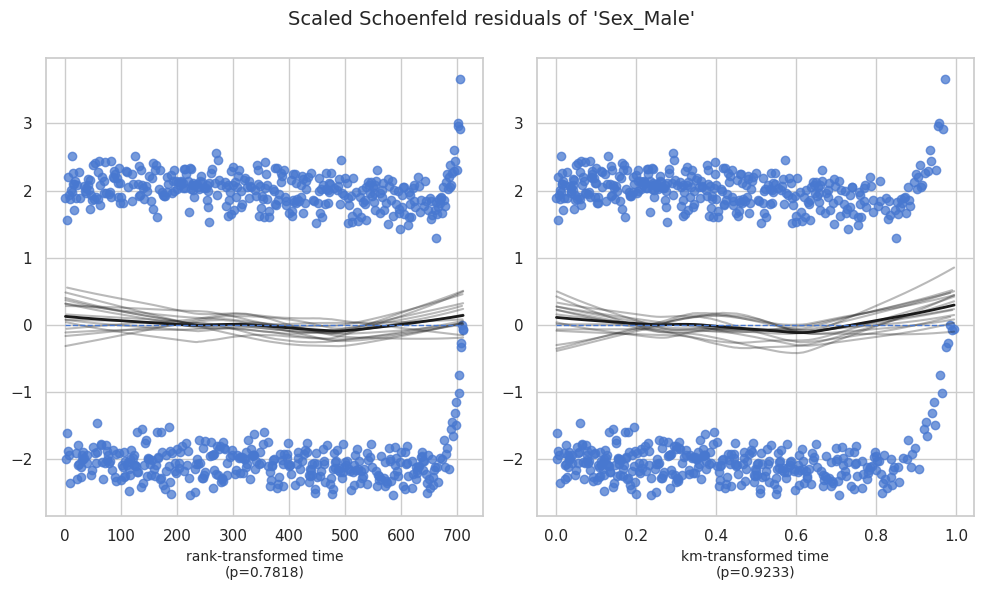

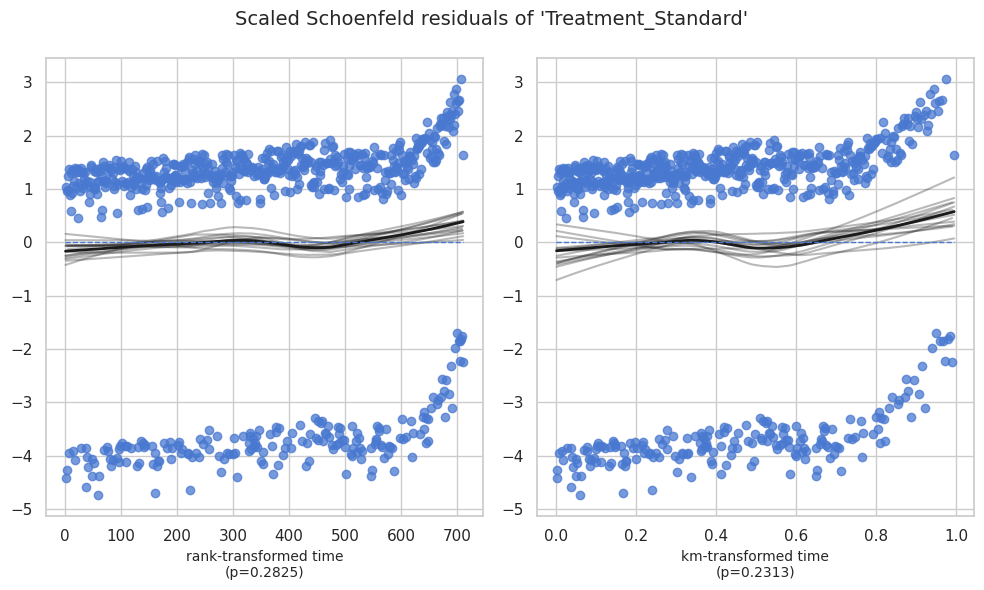

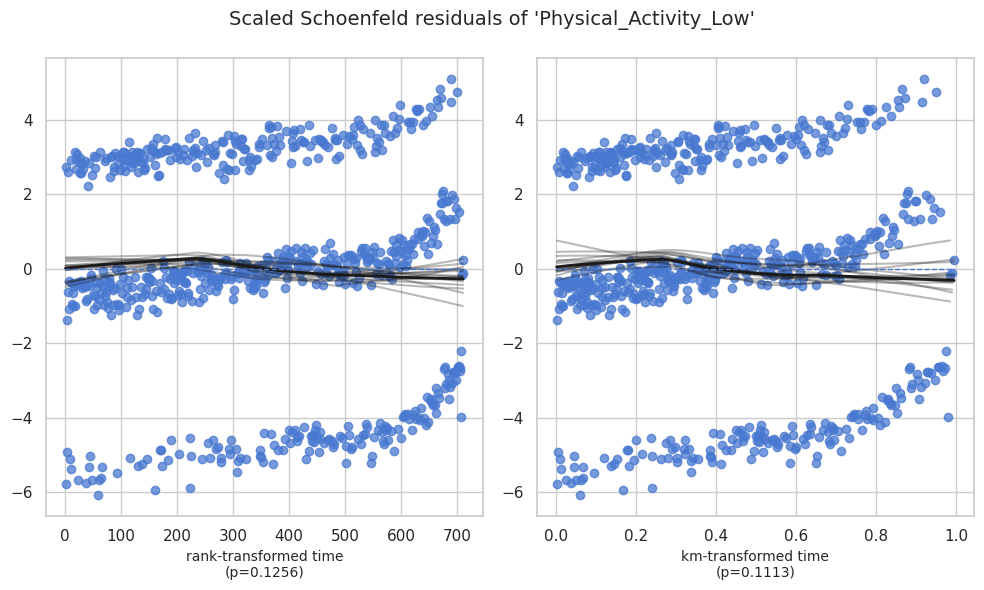

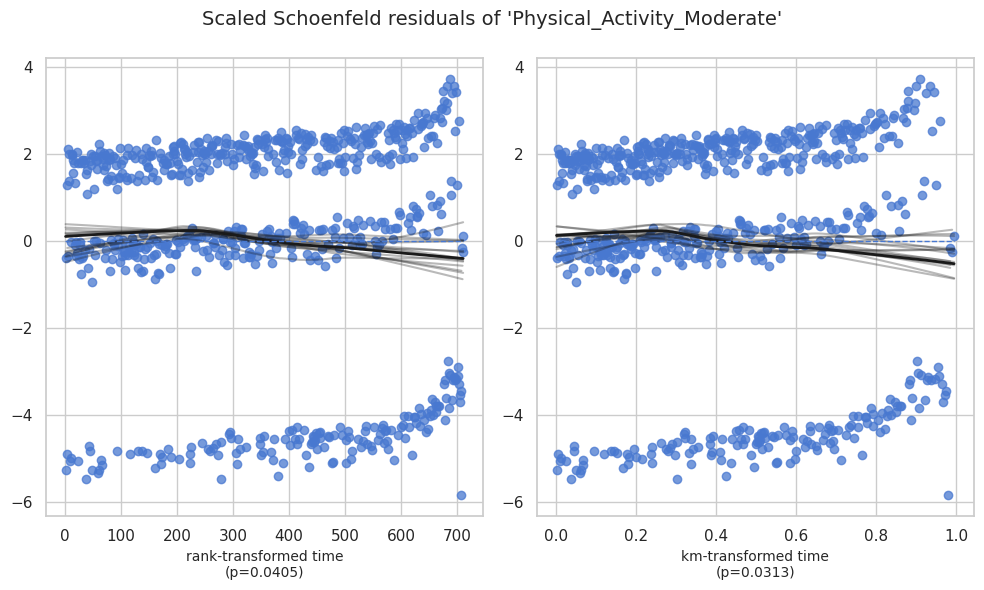

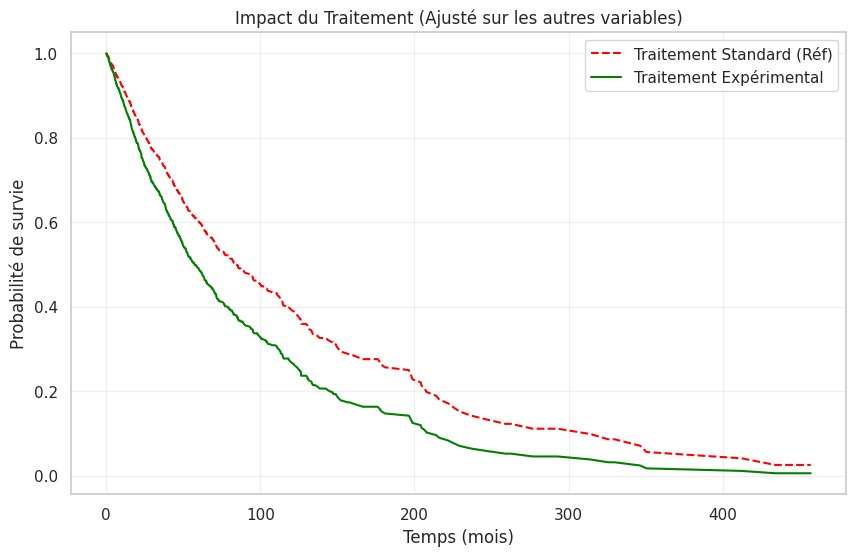

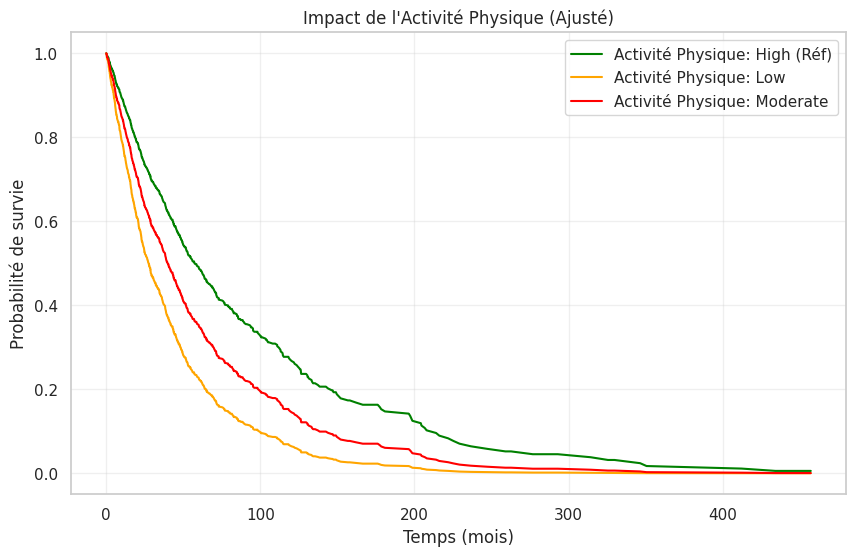

Analyse terminée.


In [ ]:
# =============================================================================
# 5. MODÉLISATION AVANCÉE : RÉGRESSION DE COX (CODE EXPERT)
# =============================================================================
# Voici l'intégration de votre code rigoureux pour l'analyse multivariée.
print("\n📊 --- 5. Analyse Multivariée (Modèle de Cox Avancé) ---")

# --- 1) Préparer les données (sélection des colonnes utiles) ---
cox_cols = ["Time_to_Event", "Event_Observed", "Sex", "Age", "Smoker", "Treatment", "Physical_Activity"]
df_cox = df[cox_cols].copy()

# Convertir les variables catégorielles (One-Hot Encoding)
# drop_first=True évite la colinéarité
df_cox = pd.get_dummies(df_cox, columns=["Sex", "Treatment", "Physical_Activity"], drop_first=True)

# --- 2) Ajuster le modèle de Cox ---
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="Time_to_Event", event_col="Event_Observed")

# --- 3) Afficher les résultats ---
print("\n--- Résumé du Modèle ---")
cph.print_summary()

# Affichage clair des Hazard Ratios
hr = np.exp(cph.params_).sort_values(ascending=False)
print("\n--- Classement des Facteurs de Risque (Hazard Ratios) ---\n", hr)

# --- 4) Vérifier l’hypothèse de proportionnalité des risques ---
print("\n--- Vérification des Hypothèses (Proportional Hazards) ---")
cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=True)
plt.show() # Force l'affichage des graphes de diagnostic

# --- 5) Visualiser des courbes de survie ajustées (Profils types) ---
# Création d'un profil 'moyen' (Baseline)
baseline = df_cox.drop(columns=["Time_to_Event", "Event_Observed"]).median(numeric_only=True).to_frame().T

# Identification automatique des colonnes dummies
treat_cols = [c for c in df_cox.columns if c.startswith("Treatment_")]
sex_cols = [c for c in df_cox.columns if c.startswith("Sex_")]
pa_cols = [c for c in df_cox.columns if c.startswith("Physical_Activity_")]

def make_profile(base_row, set_one_cols=None, set_zero_cols=None):
    """Copie base_row et force certaines colonnes à 1 ou 0."""
    prof = base_row.copy()
    if set_zero_cols:
        for c in set_zero_cols:
            if c in prof.columns: prof.loc[:, c] = 0
    if set_one_cols:
        for c in set_one_cols:
            if c in prof.columns: prof.loc[:, c] = 1
    return prof

# A. Courbes ajustées selon le Traitement
if len(treat_cols) == 1:
    plt.figure(figsize=(10, 6))
    treat_dummy = treat_cols[0]
    # Profils : Standard (0) vs Experimental (1)
    p_ref = make_profile(baseline, set_zero_cols=[treat_dummy])
    p_alt = make_profile(baseline, set_one_cols=[treat_dummy])

    sf_ref = cph.predict_survival_function(p_ref)
    sf_alt = cph.predict_survival_function(p_alt)

    plt.plot(sf_ref.index, sf_ref.values, label="Traitement Standard (Réf)", color='red', linestyle='--')
    plt.plot(sf_alt.index, sf_alt.values, label="Traitement Expérimental", color='green')
    plt.title("Impact du Traitement (Ajusté sur les autres variables)")
    plt.xlabel("Temps (mois)")
    plt.ylabel("Probabilité de survie")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# B. Courbes ajustées selon l'Activité Physique
if len(pa_cols) >= 1:
    plt.figure(figsize=(10, 6))
    # Réf : Activité High (toutes dummies à 0 si High est la ref implicite via drop_first)
    p_ref = make_profile(baseline, set_zero_cols=pa_cols)
    sf_ref = cph.predict_survival_function(p_ref)
    plt.plot(sf_ref.index, sf_ref.values, label="Activité Physique: High (Réf)", color='green')

    colors = ['orange', 'red']
    for i, col in enumerate(pa_cols):
        p_alt = make_profile(baseline, set_zero_cols=pa_cols, set_one_cols=[col])
        sf_alt = cph.predict_survival_function(p_alt)
        # On nettoie le nom pour la légende (ex: "Physical_Activity_Low" -> "Low")
        label_clean = col.replace("Physical_Activity_", "")
        plt.plot(sf_alt.index, sf_alt.values, label=f"Activité Physique: {label_clean}", color=colors[i % len(colors)])

    plt.title("Impact de l'Activité Physique (Ajusté)")
    plt.xlabel("Temps (mois)")
    plt.ylabel("Probabilité de survie")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("Analyse terminée.")

**Interprétation des Résultats du Modèle de Cox :**

L'analyse des coefficients (et des Hazard Ratios) révèle les dynamiques suivantes  :

*  Activité Physique (Facteur Majeur) : C'est le déterminant le plus puissant. Par rapport à une activité "High" (référence), avoir une activité "Low" double le risque de décès (HR ≈ 2.08, p < 0.005). Une activité "Moderate" augmente aussi le risque (HR ≈ 1.46).

*  Tabagisme : Être fumeur augmente le risque de décès d'environ 48% (HR ≈ 1.48), un résultat statistiquement très significatif.

*  Traitement : Le traitement "Standard" est associé à un sur-risque de 41% (HR ≈ 1.41) par rapport au traitement expérimental (référence implicite). Cela suggère que le nouveau traitement expérimental est plus efficace.

*  Sexe : Confirmant notre analyse Kaplan-Meier, le coefficient est proche de 0 (HR ≈ 0.97) et la p-value est élevée. Le sexe n'a pas d'impact ajusté significatif.

*  Âge : Chaque année supplémentaire augmente le risque d'environ 3% (HR ≈ 1.03). L'effet est faible à l'unité, mais cumulatif sur la durée.



---


# **Conclusion**

Cette étude nous a permis de passer de la donnée brute à des insights cliniques actionnables :

1.  Nous avons confirmé que le Sexe n'est pas un facteur discriminant dans cette cohorte.

2.  Nous avons quantifié l'importance vitale de l'Activité Physique et l'arrêt du Tabac.

3.  Nous avons mis en évidence la supériorité du Traitement Expérimental sur le traitement Standard, ce qui pourrait justifier son adoption généralisée sous réserve de validation médicale.

Le modèle de Cox s'est avéré robuste (Concordance index de 0.64) pour hiérarchiser ces facteurs de risque.